# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-10 11:49:31,592] A new study created in memory with name: no-name-214fec0d-6f50-4696-968c-311041a0685d
[I 2026-04-10 11:49:31,740] Trial 0 finished with value: 0.7 and parameters: {'n_estimators': 165, 'max_depth': 7}. Best is trial 0 with value: 0.7.
[I 2026-04-10 11:49:31,884] Trial 1 finished with value: 0.6991869918699187 and parameters: {'n_estimators': 167, 'max_depth': 7}. Best is trial 0 with value: 0.7.
[I 2026-04-10 11:49:32,084] Trial 2 finished with value: 0.7286821705426356 and parameters: {'n_estimators': 216, 'max_depth': 11}. Best is trial 2 with value: 0.7286821705426356.
[I 2026-04-10 11:49:32,343] Trial 3 finished with value: 0.7384615384615385 and parameters: {'n_estimators': 282, 'max_depth': 13}. Best is trial 3 with value: 0.7384615384615385.
[I 2026-04-10 11:49:32,583] Trial 4 finished with value: 0.7538461538461538 and parameters: {'n_estimators': 246, 'max_depth': 14}. Best is trial 4 with value: 0.7538461538461538.
[I 2026-04-10 11:49:32,735] Trial

RF F1: 0.7538461538461538
LR F1: 0.71875
SVM F1: 0.71875
KNN F1: 0.7555555555555555


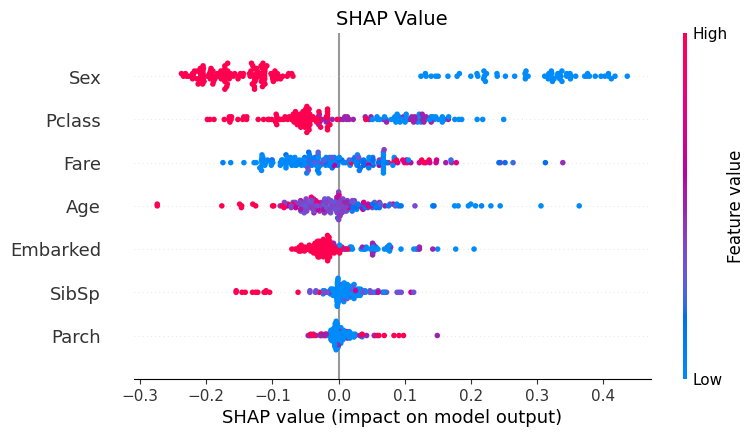

Stacking F1: 0.7538461538461538


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [3]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])

y= df["churn"]

# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=y)

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0500
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.2160
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1310
catboost,CatBoost Classifier,0.8584,0.8641,0.4637,0.7472,0.5708,0.4918,0.5126,2.4560
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.1310
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0350
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.0900
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0150
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0100
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0100


In [4]:
# 상위 4개 모델은 Adaboost, Light GBM, GBM classifier, Catboost. 해당 4개 모델 사용

churn 컬럼을 target으로 한 분류모델

In [5]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# customer_id는 불필요하므로 제외
df = df.drop(columns=["customer_id"], errors="ignore")

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)
df.info() # 결측치 없음을 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [6]:
# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

# 인코딩은 첫 종류부터 나오는 순서에 따라 0, 1, 2의 형식으로 인코딩된다.
df['country'] = le_country.fit_transform(df['country']) # 프랑스는 0, 스페인은 1, 독일은 2
df['gender'] = le_gender.fit_transform(df['gender']) # 여성은 0, 남성은 1

In [7]:
df.describe() 

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.746300,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,0.827529,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,0.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,0.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,0.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,1.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,2.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


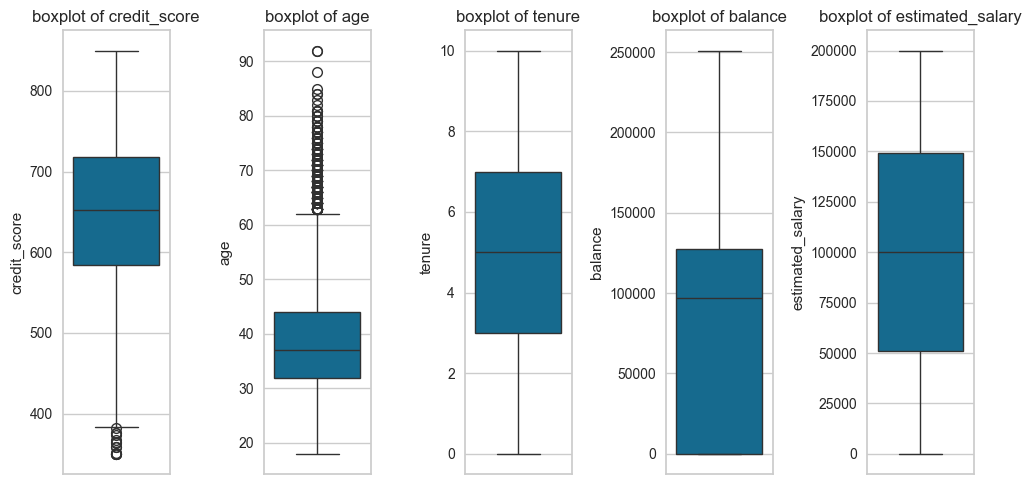

In [8]:
# blance에서 이상치가 있어보이며, products_number, credit_card, active_member, country, gender의 경우, 범주형으로 보임.
# 따라서 boxplot을 그릴 때, 해당 4개의 컬럼은 제외. 단, 단위가 다르므로, 각각의 boxplot 작성
import seaborn as sns # 시각화 모듈 seaborn 적용
import matplotlib.pyplot as plt # 시각화 모듈 matplotlib.pyplot 적용

fig, ax = plt.subplots(1, 5, figsize=(10,5)) # 각 컬럼별 boxplot 작성을 위한 구역나누기
cols = ["credit_score","age","tenure","balance","estimated_salary"] # 작성할 컬럼
for i, col in enumerate(cols) :
    sns.boxplot(df[col], ax=ax[i]) # 각 컬럼별 박스플롯 생성 후 자리 할당
    ax[i].set_title(f"boxplot of {col}") # 각 박스플롯의 title 생성
plt.tight_layout()
plt.show()

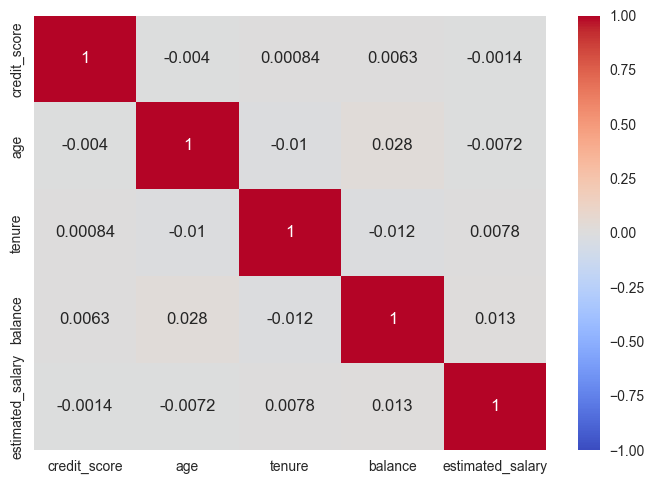

In [9]:
# 위에 따르면 credit_score는 낮은 값의 이상치, age는 높은 값의 이상치가 보임. 그 외의 컬럼에는 이상치가 없음.
# 다음은 각 수치형 컬럼별 상관계수를 확인한다.

cormat = df[cols].corr() # correlation matrix 생성
plt.figure(figsize=(7,5)) 
sns.heatmap(cormat,annot=True,cmap="coolwarm",vmin=-1,vmax=1) # 행렬에 따른 히트맵 생성 (상관관계는 -1 ~ 1로 정의한다.)
plt.tight_layout()
plt.show()

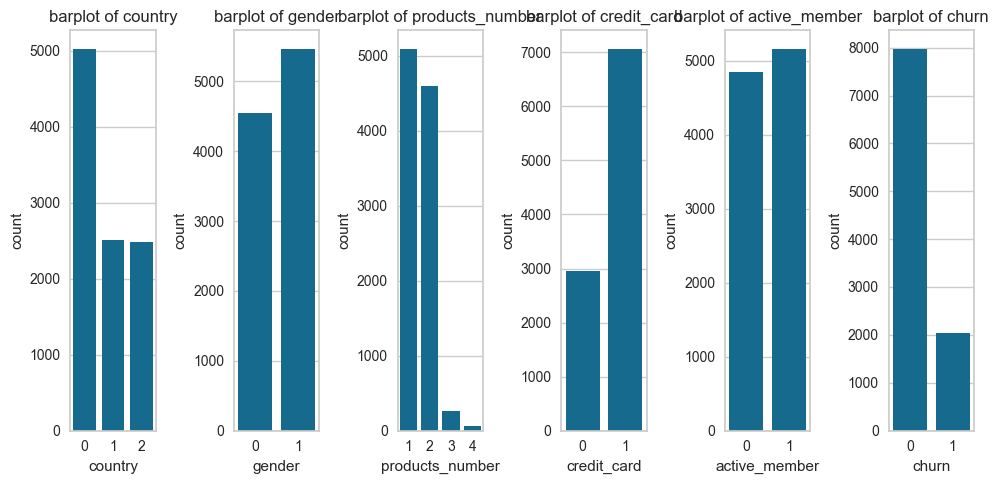

In [10]:
# 위에 따르면 각 feature 간 상관관계도 없어보임을 확인.

# 다음은 범주형이라 여겨지는 4개의 컬럼에 대해서 막대그래프를 작성

fig, ax = plt.subplots(1, 6, figsize=(10,5)) # 각 컬럼별 boxplot 작성을 위한 구역나누기
cols2 = ["country","gender","products_number", "credit_card", "active_member", "churn"] # 작성할 컬럼 (target 포함)
for i, col in enumerate(cols2) :
    sns.barplot(df[col].value_counts(), ax=ax[i]) # 각 컬럼별 박스플롯 생성 후 자리 할당
    ax[i].set_title(f"barplot of {col}") # 각 박스플롯의 title 생성
plt.tight_layout()
plt.show()

In [11]:
# 막대그래프에 따르면 금융상품이 적은 고객이 훨씬 많고, 신용 카드 보유 고객이 약 2배 넘게 더 많으며, 활동적인 회원이 유사하지만 조금 더 많다.
# target에 대해서는 이탈한 고객 vs 유지 고객이 2:8 정도로 나타나고 있다.
# 또한 독일, 스페인은 비숫한 수치이지만, 프랑스의 경우 고객 수가 2배 가까이 더 많고, 성멸의 경우 남성이 더 많은 것으로 확인되었다.

In [12]:
# 종합적인 결론으로 credit_score는 낮은 값의 이상치, age는 높은 값의 이상치가 보임. 그 외의 컬럼에는 이상치가 없다.
# 또한 컬럼 간 상관관계가 없는 것으로 보아, 나이에 따른, 혹은 신용 점수에 따른 등의 연관을 짓는 의미가 없이, 서로 독립적인 지표를 보인다.
# 이는 어느 하나의 수치가 변동되어도, 다른 지표 상에는 그것이 바뀌어도, 안바뀌어도 상관이 없다는 결과이다.
# 해당 데이터셋의 경우는 은행의 상품 수가 1개, 2개인 경우가 대부분이므로, 이에 관해서 결과 대한 편향이 있을 수 있다.

In [13]:
# 분석 시, 결측치는 없어, 대체할 필요가 없이 그대로 진행한다.
# 이상치의 경우, 나이의 경우는 노인의 경우, 스마트뱅킹보다는 창구거래를 일반적으로 많이 사용하며
# 노화에 따라 건강이 악화되어 몸을 가누기 힘들어지면서 창구에 가는 경우가 적어지면서 이탈이 될 수도 있기 때문에 이상치 대체는 하지 않는다.
# 신용 점수의 경우, 낮다면 그 원인으로 인해서 고객 이탈 가능성이 높아질 수도 있으므로, 이상치 대체는 하지 않는다.
# 즉, 현재의 데이터 그대로 분석을 진행한다. (스케일링의 경우 후술에 따름.)
# 단, 변수 중 고객 이탈에 연관이 없어보이는 변수는 제외 (county, customer_id)
# customer_id는 고객 고유 ID이므로 분석에는 연관이 없다.
# country의 경우, 나라에 따른 이탈률은 상식적으로 연관이 없다.

In [14]:
# 먼저 data를 train : valid = 8 : 2 의 비율로 분할한다.
# X, y 할당
X = df.drop(columns=["country", "churn"], errors="ignore")
y = df["churn"]

# train valid split as ratio 8 : 2
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 단, 변수 별로 단위가 다르기 때문에 범주형 자료를 제외한 일반 수치형 컬럼은 스케일링을 시행한다.
# 이상치들은 정당한 이상치들이므로, 표준화 스케일링을 시도해도 괜찮을 것이다.

from sklearn.compose import ColumnTransformer # 스케일링 시, 범주형을 걸러내기 위한 모듈 적용
from sklearn.preprocessing import StandardScaler # 표준화 스케일링 모듈 적용

# 수치형만 스케일하는 함수 작성
ct = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), cols)
    ],
    remainder="passthrough"  # 나머지는 그대로 둠
)

X_train_scaled = ct.fit_transform(X_train) # 스케일링 및 그 형식 저장
X_valid_scaled = ct.transform(X_valid) # 저장된 형식에 맞게 스케일링

In [15]:
# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기 # 선정 : Adaboost, Light GBM, GBM classifier, Catboost
# (옵션 리스트는 구글 검색 필요 할 것)
# 각 parameter 별로, n_estimators는 50~300, learning_rate는 0.01~0.5, max_depth는 3~15로 통일한다.
# 또한 코드 실행 시 마다 수치가 달라지는 걸 방지하기 위해 random_state를 이용해 시드값 42로 고정한다.
# parameter 성정 기준은 f1_score로 통일한다.
from sklearn.metrics import f1_score

# Adaboost trial 함수 (max_depth 없음)
from sklearn.ensemble import AdaBoostClassifier
def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
    }
    model = AdaBoostClassifier(**params, random_state=42)
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_valid_scaled)
    return f1_score(y_valid, pred)

# Light GBM trial function
from lightgbm import LGBMClassifier
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1) # 성능 향상의 문제에 대해 경고구문 풀력 생략을 위해 verbose=-1 적용
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_valid_scaled)
    return f1_score(y_valid, y_pred)

# GBM Classifier trial function
from sklearn.ensemble import GradientBoostingClassifier
def objective_gbc(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
    }

    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_valid_scaled)
    return f1_score(y_valid, y_pred)

# CatBoost trial function
from catboost import CatBoostClassifier
def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
    }

    model = CatBoostClassifier(**params, random_state=42, verbose=0) # catboost의 경우, 학습구문을 생략하기 위해 verbose=0 적용
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_valid_scaled)
    return f1_score(y_valid, y_pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
import optuna # optuna 모듈 적용

# 방향은 maximize, n_trials는 10으로 통일
study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=10)

study_LGBM = optuna.create_study(direction='maximize')
study_LGBM.optimize(objective_lgbm, n_trials=10)

study_GBC = optuna.create_study(direction='maximize')
study_GBC.optimize(objective_gbc, n_trials=10)

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=10)

[I 2026-04-10 11:50:26,950] A new study created in memory with name: no-name-6140942c-6c77-4d3b-9fbf-081f65a401c4
[I 2026-04-10 11:50:28,170] Trial 0 finished with value: 0.5493171471927162 and parameters: {'n_estimators': 169, 'learning_rate': 0.3215401718205275}. Best is trial 0 with value: 0.5493171471927162.
[I 2026-04-10 11:50:29,164] Trial 1 finished with value: 0.5515151515151515 and parameters: {'n_estimators': 138, 'learning_rate': 0.37897511269340145}. Best is trial 1 with value: 0.5515151515151515.
[I 2026-04-10 11:50:30,173] Trial 2 finished with value: 0.5484848484848485 and parameters: {'n_estimators': 140, 'learning_rate': 0.3696070186829958}. Best is trial 1 with value: 0.5515151515151515.
[I 2026-04-10 11:50:31,322] Trial 3 finished with value: 0.5531914893617021 and parameters: {'n_estimators': 157, 'learning_rate': 0.38612642143043374}. Best is trial 3 with value: 0.5531914893617021.
[I 2026-04-10 11:50:32,841] Trial 4 finished with value: 0.5415384615384615 and para

In [24]:
print(study_ada.best_params)
print(study_LGBM.best_params)
print(study_GBC.best_params)
print(study_cat.best_params)

{'n_estimators': 157, 'learning_rate': 0.38612642143043374}
{'n_estimators': 271, 'learning_rate': 0.034879786777408876, 'max_depth': 6, 'num_leaves': 90, 'min_child_samples': 17}
{'n_estimators': 169, 'learning_rate': 0.40183983523656674, 'max_depth': 14}
{'iterations': 94, 'learning_rate': 0.10917295154082785, 'max_depth': 9}


In [17]:
# 탐색한 최적화된 parameter로 모델 생성
adac = AdaBoostClassifier(**study_ada.best_params, random_state=42)
lgbc = LGBMClassifier(**study_LGBM.best_params, random_state=42)
gbmc = GradientBoostingClassifier(**study_GBC.best_params, random_state=42)
catc = CatBoostClassifier(**study_cat.best_params, random_state=42, verbose=0) # catboost의 경우, 학습구문을 생략하기 위해 verbose=0 적용

# 생성된 모델들을 train set을 이용해 모델 학습
adac.fit(X_train_scaled,y_train)
lgbc.fit(X_train_scaled,y_train)
gbmc.fit(X_train_scaled,y_train)
catc.fit(X_train_scaled,y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('AdaBoost', adac), ('LGMB', lgbc), ('GBM', gbmc), ('CatBoost', catc)]:
    pred = model.predict(X_valid_scaled)
    print(name, "F1:", f1_score(y_valid, pred))

AdaBoost F1: 0.5531914893617021
LGMB F1: 0.5552147239263804
GBM F1: 0.547945205479452
CatBoost F1: 0.5625965996908809


In [18]:
# 모델별로 F1-score는 위와 같으며, 순위는 CatBoost, AdaBoost, LGBM, GBM의 순서이다.

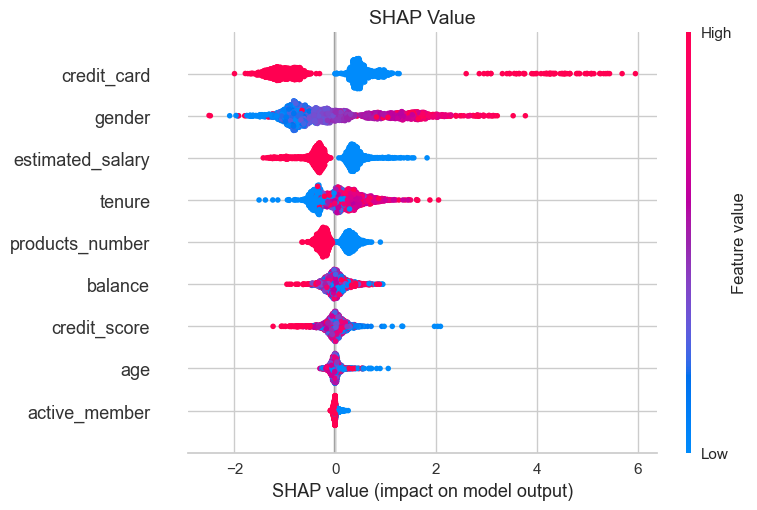

In [19]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)
# SHAP value는 Tree기반이며, 이는 속도도 빠르고, 대용량 처리에 적합한 LGBM에 대해서 나타낸다.
import shap

explainer = shap.TreeExplainer(lgbc)
shap_values = explainer.shap_values(X_valid_scaled)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid_scaled, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


In [20]:
# 위의 SHAP value에 대한 해석은 다음과 같다.
# 1. 신용카드 보유 여부는 고객 이탈율을 알기 어렵다. 보유하고 있음에도, 이탈할 가능성이 높을 수 있다. 단, 보유하지 않았다면 이탈할 가능성이 높다.
# 2. 성별의 경우, 남성이 여성보다 고객 이탈율이 더 높음을 알 수 있다. 이는 성별에 따라서 어떤 것을 중요시 하는가에 대한 성향으로 인한 결과일 것이다.
# 3. 추정 연봉이 낮다면 고객 이탈 확률이 증가한다. 미래에 보유할 돈이 적어진다면 그만큼 거래의 활동성이 줄을 것이다.
# 4. 은행을 오랫동안 이용한다면 이탈율이 증가할 것이다. 이는 해당 은행의 서비스에 너무 익숙해져 관심도가 갈수록 낮아지면서 생기는 현상이다.
# 혹은 신규 가입 고객의 상품에 더 치중한다면 기존 고객의 중요도가 상대적으로 떨어지므로, 이로 인해 기존 고객이 이탈할 가능성이 증가할 것이다.
# 5. 은행에서 이용하는 상품의 수가 적다면 이탈율이 증가한다. 해당 은행에 대한 관심 또는 서비스 이용 희망이 비교적 적다는 것이고, 이로인해 이탈할 가능성이 증가할 것이다.
# 6. 계좌 잔액은 고객의 이탈율을 알기 어렵다. 잔액은 고객의 충성도가 아니며, 단독으로는 설명하기 어려운 변수이다. 혹은 비선형의 관계를 가질 수도 있음을 염두한다.
# 7. 신용 점수는 고객의 이탈율을 알기 어렵다. 신용 점수는 신용 리스크를 설명하기 위한 변수이다. 다만, 점수가 낮다면 이탈할 가능성이 증가한다.
# 8. 나이는 고객 이탈율을 알기 어렵다. 거동이 불편한 노인일수록 고객 이탈율이 더 높을 것이라 예상하였으나, 나이만으로는 설명하지 못하는 부분이 있기 때문일 것으로 추정된다.
# 9. 활성 고객 여부는 고객 이탈율에 영향을 거의 주지 못한다. 다만, 비활성 고객이 미세하지만 이탈율 증가에 기여한다는 것을 알 수 있다.

# 즉, 추정 연봉, 은행 이용 기간, 상품 수, 성별이 영향을 확실히 줄 수 있으며, 이에 대한 대책이 필요하다는 결론이다.
# 이중 은행 이용 기간에 대한 결과에 대해 인사이트를 제안한다.
# 신규 고객 유치도 필요하지만 너무 이에만 열중한다면, 기존 고객에 대한 중요도는 떨어져, 기존 고객 이탈이라는 역효과가 발생할 것이다.
# 따라서 기존 고객들도 당행을 꾸준히 이용할 수 있게끔, 기존 고객만을 위한 상품 또한 필요하다.
# 꾸준히 이용해온 고객들에게 멤버십 혜택, 혹은 마일리지 형식의 상품을 주는 것도 충분히 도움이 될 수 있는 아이디어라 생각한다.
# 이는 은행 이용 기간에 대한 인사이트이지만, 이에만 해당하지 않고, 이는 상품 수에도 영향을 줄 수 있다.
# 만약 고객이 이러한 상품에 더 가입한다면 해당 고객의 이용하는 상품 수가 증가한다는 것이기도 하며, 따라서 이탈율을 줄이기 위한 효과적인 방법이라고 생각한다.

In [21]:
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) F1-score or Accuracy
from sklearn.ensemble import StackingClassifier

# 전방은 Adaboost, LGBM, GBM을 이용하며 후방은 CatBoost로 마무리한다.
# 해당 모델들은 최적화된 모델인 adac, lgbc, gbmc, catc를 이용한다.

stack_md = StackingClassifier(
    estimators = [("ada", adac), ("LGBM", lgbc), ("GBM", gbmc)],
    final_estimator = catc, stack_method="predict", n_jobs=-1 # n_jobs=-1로 CPU 사용에 제한을 없앤다.
)

stack_md.fit(X_train_scaled, y_train) # train set을 이용해 학습 진행

y_predict = stack_md.predict(X_valid_scaled) # 예측값 도출

print(f"Stack Model F1-score : {f1_score(y_valid, y_predict)}")

Stack Model F1-score : 0.563338301043219


In [22]:
# 해당 모델들을 이용해 도출한 스택모델의 F1-score는 0.5538로 도출되었다.

In [23]:
# 전체적인 흐름과 결론은 다시 정리해서 작성한다.

# 전처리의 경우 또한 변수 선택에 대해서는 다음과 같다.

# 분석 시, 결측치는 없어, 대체할 필요가 없이 그대로 진행한다.
# 이상치의 경우, 나이의 경우는 노인의 경우, 스마트뱅킹보다는 창구거래를 일반적으로 많이 사용하며
# 노화에 따라 건강이 악화되어 몸을 가누기 힘들어지면서 창구에 가는 경우가 적어지면서 이탈이 될 수도 있기 때문에 이상치 대체는 하지 않는다.
# 신용 점수의 경우, 낮다면 그 원인으로 인해서 고객 이탈 가능성이 높아질 수도 있으므로, 이상치 대체는 하지 않는다.
# 단, 변수 중 고객 이탈에 연관이 없어보이는 변수는 제외한다. (county, customer_id)
# customer_id는 고객 고유 ID이므로 분석에는 연관이 없다.
# country의 경우, 나라에 따른 이탈률은 상식적으로 연관이 없다.
# 변수 별로 단위가 다르기 때문에 범주형 자료를 제외한 일반 수치형 컬럼은 스케일링을 시행한다.
# 이상치들은 정당한 이상치들이므로, 표준화 스케일링을 시도해도 괜찮을 것이다.

# EDA 해석에 경우는 다음과 같다.

# 종합적인 결론으로 credit_score는 낮은 값의 이상치, age는 높은 값의 이상치가 보이며, 그 외의 컬럼에는 이상치가 없다.
# 또한 컬럼 간 상관관계가 없는 것으로 보아, 나이에 따른, 혹은 신용 점수에 따른 등의 연관을 짓는 의미가 없다. 즉, 서로 독립적인 지표를 보인다.
# 이는 어느 하나의 수치가 변동되어도, 다른 지표 상에는 그것이 바뀌어도, 안바뀌어도 상관이 없다는 결과이다.
# 해당 데이터셋의 경우는 은행의 상품 수가 1개, 2개인 경우가 대부분이므로, 이에 관해서 결과 대한 편향이 있을 수 있다.

# ML 모델 선정기준은 처음 Auto ML (pycaret)의 F1-score의 순위에 따라 선정하였으며, 각 파라미터는 일반적으로 추천되는 범위를 이용하였다.
# 학습 수가 너무 많으면 시간이 오래걸리고, 너무 적으면 학습이 잘 되지 않아, 적당한 범위를 이용하였다.

# 마지막으로 SHAP value에 대한 인사이트는 다음과 같다.

# 추정 연봉, 은행 이용 기간, 상품 수, 성별이 영향을 확실히 줄 수 있으며, 이에 대한 대책이 필요하다는 결론이다.
# 이중 은행 이용 기간에 대한 결과에 대해 인사이트를 제안한다.
# 신규 고객 유치도 필요하지만 너무 이에만 열중한다면, 기존 고객에 대한 중요도는 떨어져, 기존 고객 이탈이라는 역효과가 발생할 것이다.
# 따라서 기존 고객들도 당행을 꾸준히 이용할 수 있게끔, 기존 고객만을 위한 상품 또한 필요하다.
# 꾸준히 이용해온 고객들에게 멤버십 혜택, 혹은 마일리지 형식의 상품을 주는 것도 충분히 도움이 될 수 있는 아이디어라 생각한다.
# 이는 은행 이용 기간에 대한 인사이트이지만, 이에만 해당하지 않고, 이는 상품 수에도 영향을 줄 수 있다.
# 만약 고객이 이러한 상품에 더 가입한다면 해당 고객의 이용하는 상품 수가 증가한다는 것이기도 하며,
# 따라서 이탈율을 줄이기 위한 효과적인 방법이라고 생각한다.